In [76]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [77]:
np.random.seed(0)

In [78]:
x = np.random.rand(100, 1)
e = np.random.randn(100, 1)
y = 2*x + 1 + e*0.1

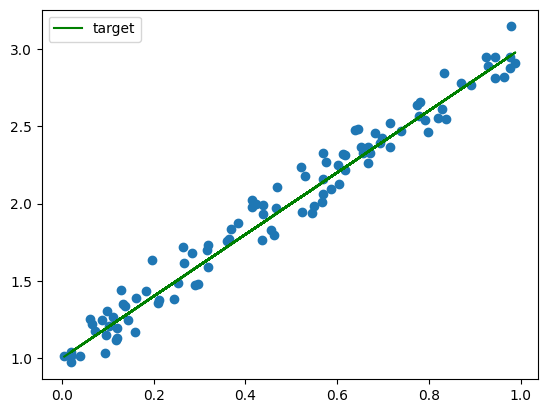

In [79]:
plt.scatter(x, y)
plt.plot(x, (2*x + 1), color = 'green', label='target') # 그래프 선 이름
plt.legend()
plt.show()

In [80]:
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [81]:
w = torch.randn(1, requires_grad=True) # 나중에 gradient 추적할거임
b = torch.randn(1, requires_grad=True) # 나중에 gradient 추적할거임

In [82]:
w

tensor([1.0157], requires_grad=True)

In [92]:
learning_rate = 0.1

In [93]:
y_pred = w*x + b
y_pred

tensor([[2.0950],
        [2.3817],
        [2.1879],
        [2.0882],
        [1.8793],
        [2.2623],
        [1.9033],
        [2.6859],
        [2.8098],
        [1.8100],
        [2.5135],
        [2.0607],
        [2.1281],
        [2.7442],
        [1.2717],
        [1.2994],
        [1.1842],
        [2.5840],
        [2.4902],
        [2.6484],
        [2.8356],
        [2.5263],
        [1.9445],
        [2.4942],
        [1.3531],
        [2.2520],
        [1.3963],
        [2.7771],
        [2.0485],
        [1.8638],
        [1.6052],
        [2.4834],
        [1.9353],
        [2.1288],
        [1.1817],
        [2.2136],
        [2.2040],
        [2.2124],
        [2.7755],
        [2.3242],
        [1.7688],
        [1.9024],
        [2.3514],
        [1.2531],
        [2.2982],
        [2.3049],
        [1.5118],
        [1.3715],
        [1.6928],
        [1.7760],
        [2.1318],
        [1.9051],
        [2.8524],
        [1.3251],
        [1.5092],
        [1

In [94]:
loss = torch.mean((y_pred-y)**2)
loss
# loss.item()

tensor(0.0160, grad_fn=<MeanBackward0>)

In [95]:
loss.backward() # 역전파로 학습하는 코드
w.grad

tensor([-0.0458])

In [96]:
for epoch in range(200):
    y_pred = w*x + b                   # 순전파
    loss = torch.mean((y_pred - y)**2) # loss
    loss.backward()                      # 역전파

    with torch.no_grad(): # with문 내부에서는 그레디언트 계산 안함.
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    w.grad.zero_() # 업데이트 끝나고 나면 미니배치마다 다르게 그래디언트를 독립적으로 계산하기에 역전파를 초기화해줘야함
    b.grad.zero_() # 업데이트 끝나고 나면 미니배치마다 다르게 그래디언트를 독립적으로 계산하기에 역전파를 초기화해줘야함

    if (epoch + 1) % 20 ==0:
        print(f'epoch: {epoch+1}, loss: {loss.item():.4f}')

epoch: 20, loss: 0.0134
epoch: 40, loss: 0.0120
epoch: 60, loss: 0.0111
epoch: 80, loss: 0.0106
epoch: 100, loss: 0.0103
epoch: 120, loss: 0.0102
epoch: 140, loss: 0.0101
epoch: 160, loss: 0.0100
epoch: 180, loss: 0.0100
epoch: 200, loss: 0.0100


In [97]:
# 실제 직선: y + 2x + 1
# 실제 w: 2
# 실제 b: 1

In [98]:
print(w.item(), b.item())

1.976027488708496 1.03116774559021


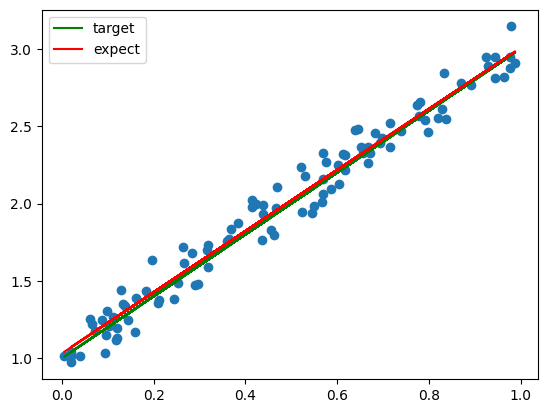

In [99]:
plt.scatter(x, y)
plt.plot(x, (2*x+1), color = 'green', label='target')
plt.plot(x, (w*x+b).detach().numpy(), color = 'red', label = 'expect')
plt.legend()
plt.show()